# Etapa 2: Modelado con Validación Segura

### Objetivos
- Dividir los datos **antes** de cualquier transformación
- Construir Pipelines seguros con `GridSearchCV` y validación cruzada
- Evaluar modelos con matriz de confusión, curva ROC y AUC
- Seleccionar y exportar el mejor modelo para despliegue


## 1. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      cross_validate, StratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                               precision_score, recall_score,
                               confusion_matrix, ConfusionMatrixDisplay,
                               roc_curve, auc, classification_report)

# Modelos vistos en clase
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier
from sklearn.svm          import SVC
from sklearn.naive_bayes  import GaussianNB
from sklearn.neighbors    import KNeighborsClassifier
from xgboost              import XGBClassifier

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

## 2. Carga y preprocesamiento del dataset

In [3]:
df = pd.read_csv("../data/heart.csv")
print(f"Shape: {df.shape}")

# One-Hot Encoding de variables categóricas
cat_cols = df.select_dtypes(include="object").columns.tolist()
df_clean = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_clean.drop("HeartDisease", axis=1)
y = df_clean["HeartDisease"]

print(f"Features: {X.shape[1]} | Ejemplos: {X.shape[0]}")
print(f"Columnas: {X.columns.tolist()}")


Shape: (918, 12)
Features: 15 | Ejemplos: 918
Columnas: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


## 3. División del dataset
**dividir siempre primero**, antes de escalar o transformar.  
El scaler se ajusta solo con datos de entrenamiento — nunca ve el conjunto de test.

Se usa `stratify=y` para mantener la proporción de clases en ambos conjuntos.


In [4]:
RANDOM_STATE = 42
TEST_SIZE    = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y          # mantiene proporción de clases
)

print(f"Train → {X_train.shape[0]} muestras | positivos: {y_train.mean()*100:.1f}%")
print(f"Test  → {X_test.shape[0]}  muestras | positivos: {y_test.mean()*100:.1f}%")


Train → 734 muestras | positivos: 55.3%
Test  → 184  muestras | positivos: 55.4%


## 4. Función reutilizable `train_pipeline`
Encapsula la lógica de entrenamiento: `Pipeline(scaler → clf)` + `GridSearchCV`.


In [5]:
def train_pipeline(X_train, y_train, model, param_grid, cv=5):
    """
    Crea y entrena un Pipeline(MinMaxScaler → model) con GridSearchCV.

    Parámetros
    ----------
    X_train    : features de entrenamiento
    y_train    : etiquetas de entrenamiento
    model      : instancia del clasificador sklearn/xgboost
    param_grid : dict de hiperparámetros (prefijo 'clf__')
    cv         : número de folds de validación cruzada

    Retorna
    -------
    grid : GridSearchCV ajustado
    """
    pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf",    model)
    ])
    grid = GridSearchCV(
        pipe, param_grid,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring="roc_auc",
        n_jobs=-1,
        return_train_score=True
    )
    grid.fit(X_train, y_train)
    return grid


def evaluate_model(grid, X_test, y_test, model_name):
    """Calcula métricas completas sobre el conjunto de test."""
    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    return {
        "Modelo":      model_name,
        "AUC-ROC":     round(roc_auc_score(y_test, y_proba), 4),
        "Accuracy":    round(accuracy_score(y_test, y_pred), 4),
        "F1-Score":    round(f1_score(y_test, y_pred), 4),
        "Precision":   round(precision_score(y_test, y_pred), 4),
        "Recall":      round(recall_score(y_test, y_pred), 4),
        "Best params": grid.best_params_,
        "CV AUC mean": round(grid.best_score_, 4),
        "grid":        grid
    }


## 5. Configuración de modelos e hiperparámetros

In [6]:
MODELS = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {
            "clf__C":      [0.01, 0.1, 1, 10],
            "clf__solver": ["lbfgs", "liblinear"]
        }
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "clf__n_estimators":    [100, 200],
            "clf__max_depth":       [None, 5, 10],
            "clf__min_samples_split": [2, 5]
        }
    ),
    "SVC": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {
            "clf__C":     [0.1, 1, 10],
            "clf__gamma": [0.01, 0.1, "scale"]
        }
    ),
    "GaussianNB": (
        GaussianNB(),
        {
            "clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    ),
    "KNeighbors": (
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11],
            "clf__weights":     ["uniform", "distance"],
            "clf__metric":      ["euclidean", "manhattan"]
        }
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
        {
            "clf__n_estimators":  [100, 200],
            "clf__max_depth":     [3, 5, 7],
            "clf__learning_rate": [0.01, 0.1, 0.2]
        }
    ),
}

## 6. Entrenamiento con validación cruzada estratificada (5-fold)

In [7]:
results = []

for name, (model, param_grid) in MODELS.items():
    print(f"{name}...", end="  ")
    grid   = train_pipeline(X_train, y_train, model, param_grid)
    result = evaluate_model(grid, X_test, y_test, name)
    results.append(result)
    print(f"CV AUC={result['CV AUC mean']:.4f} | Test AUC={result['AUC-ROC']:.4f}")

LogisticRegression...  CV AUC=0.9253 | Test AUC=0.9307
RandomForest...  CV AUC=0.9295 | Test AUC=0.9291
SVC...  CV AUC=0.9230 | Test AUC=0.9311
GaussianNB...  CV AUC=0.9199 | Test AUC=0.9451
KNeighbors...  CV AUC=0.9136 | Test AUC=0.9431
XGBoost...  CV AUC=0.9292 | Test AUC=0.9365


## 7. Tabla comparativa de métricas

In [8]:
cols = ["Modelo", "AUC-ROC", "CV AUC mean", "Accuracy", "F1-Score", "Precision", "Recall"]
ranking = pd.DataFrame([{k: v for k, v in r.items() if k in cols} for r in results])
ranking = ranking.sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
ranking.index += 1
ranking.index.name = "Rank"

# Resaltar mejores valores por columna
def highlight_max(s):
    is_max = s == s.max()
    return ["background-color: #c6efce; font-weight:bold" if v else "" for v in is_max]

metrics = ["AUC-ROC", "CV AUC mean", "Accuracy", "F1-Score", "Precision", "Recall"]
ranking.style.apply(highlight_max, subset=metrics)


,Modelo,AUC-ROC,Accuracy,F1-Score,Precision,Recall,CV AUC mean
Rank,,,,,,,
1,GaussianNB,0.945100,0.913000,0.920800,0.930000,0.911800,0.919900
2,KNeighbors,0.943100,0.891300,0.904800,0.879600,0.931400,0.913600
3,XGBoost,0.936500,0.896700,0.906400,0.910900,0.902000,0.929200
4,SVC,0.931100,0.864100,0.882600,0.846800,0.921600,0.923000
5,LogisticRegression,0.930700,0.891300,0.904800,0.879600,0.931400,0.925300
6,RandomForest,0.929100,0.875000,0.887800,0.883500,0.892200,0.929500


## 8. Ranking visual

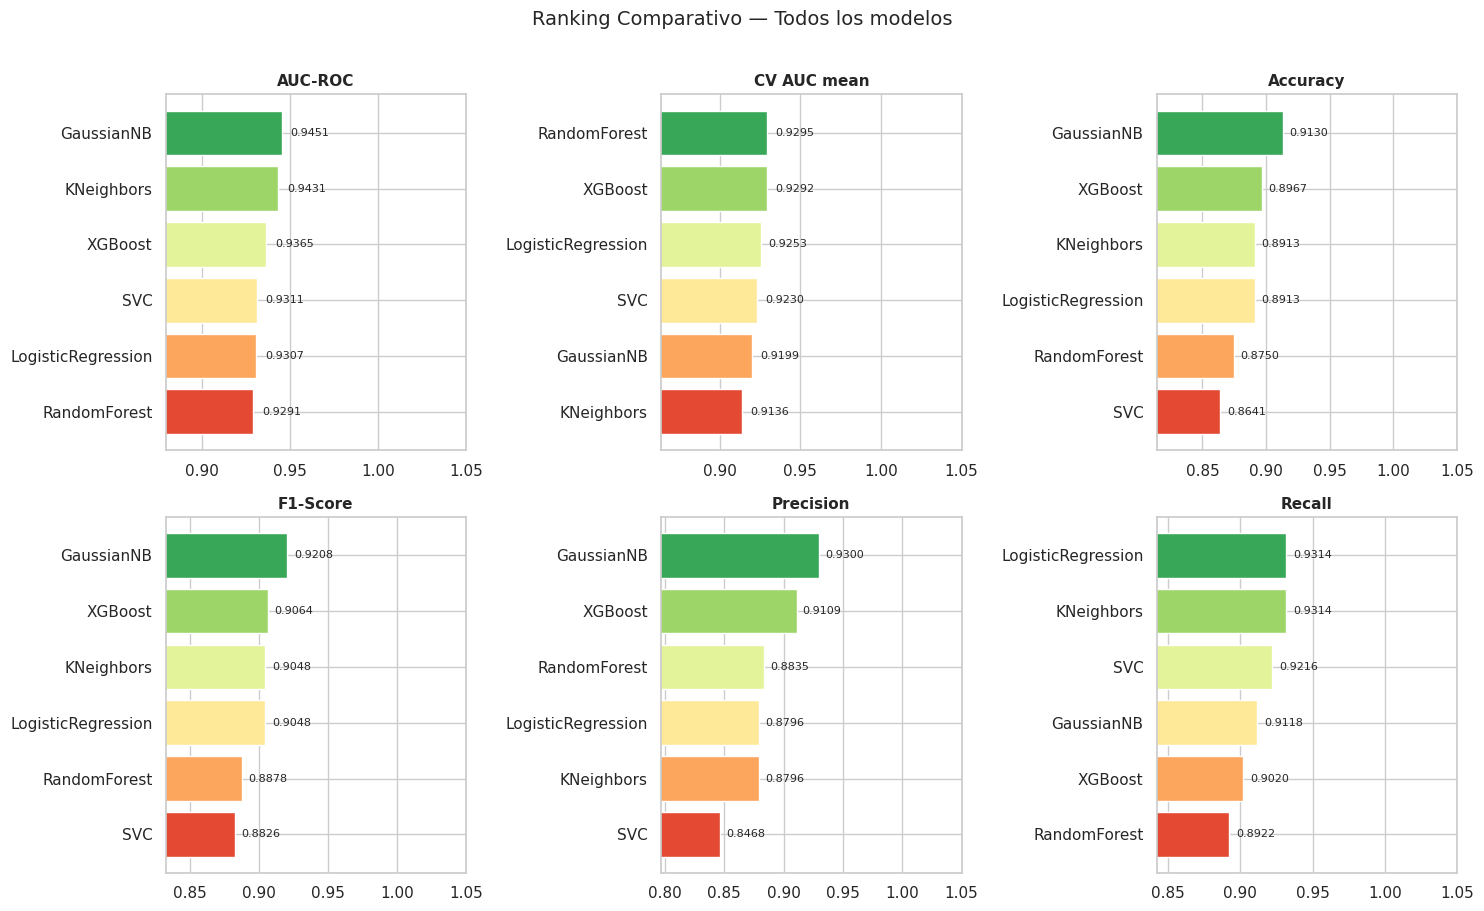

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
palette = sns.color_palette("RdYlGn", len(ranking))

for ax, metric in zip(axes, ["AUC-ROC", "CV AUC mean", "Accuracy",
                               "F1-Score", "Precision", "Recall"]):
    vals   = ranking.sort_values(metric, ascending=True)[metric].values
    models = ranking.sort_values(metric, ascending=True)["Modelo"].values

    bars = ax.barh(models, vals, color=palette, edgecolor="white")
    ax.set_xlim(max(0, vals.min() - 0.05), 1.05)
    ax.set_title(metric, fontsize=11, fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f"{v:.4f}", va="center", fontsize=8)

plt.suptitle("Ranking Comparativo — Todos los modelos", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 9. Curvas ROC

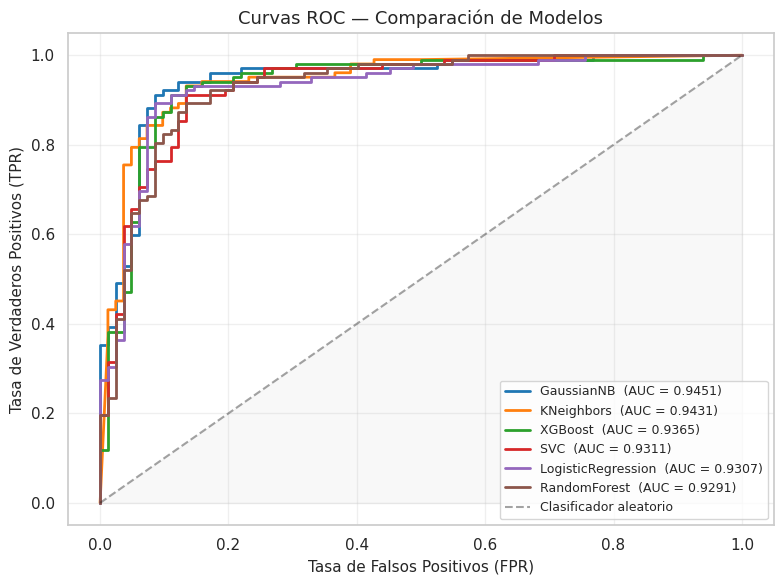

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors

sorted_results = sorted(results, key=lambda x: x["AUC-ROC"], reverse=True)

for i, r in enumerate(sorted_results):
    y_proba = r["grid"].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f"{r['Modelo']}  (AUC = {r['AUC-ROC']:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Clasificador aleatorio")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=11)
ax.set_title("Curvas ROC — Comparación de Modelos", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Matrices de confusión — todos los modelos

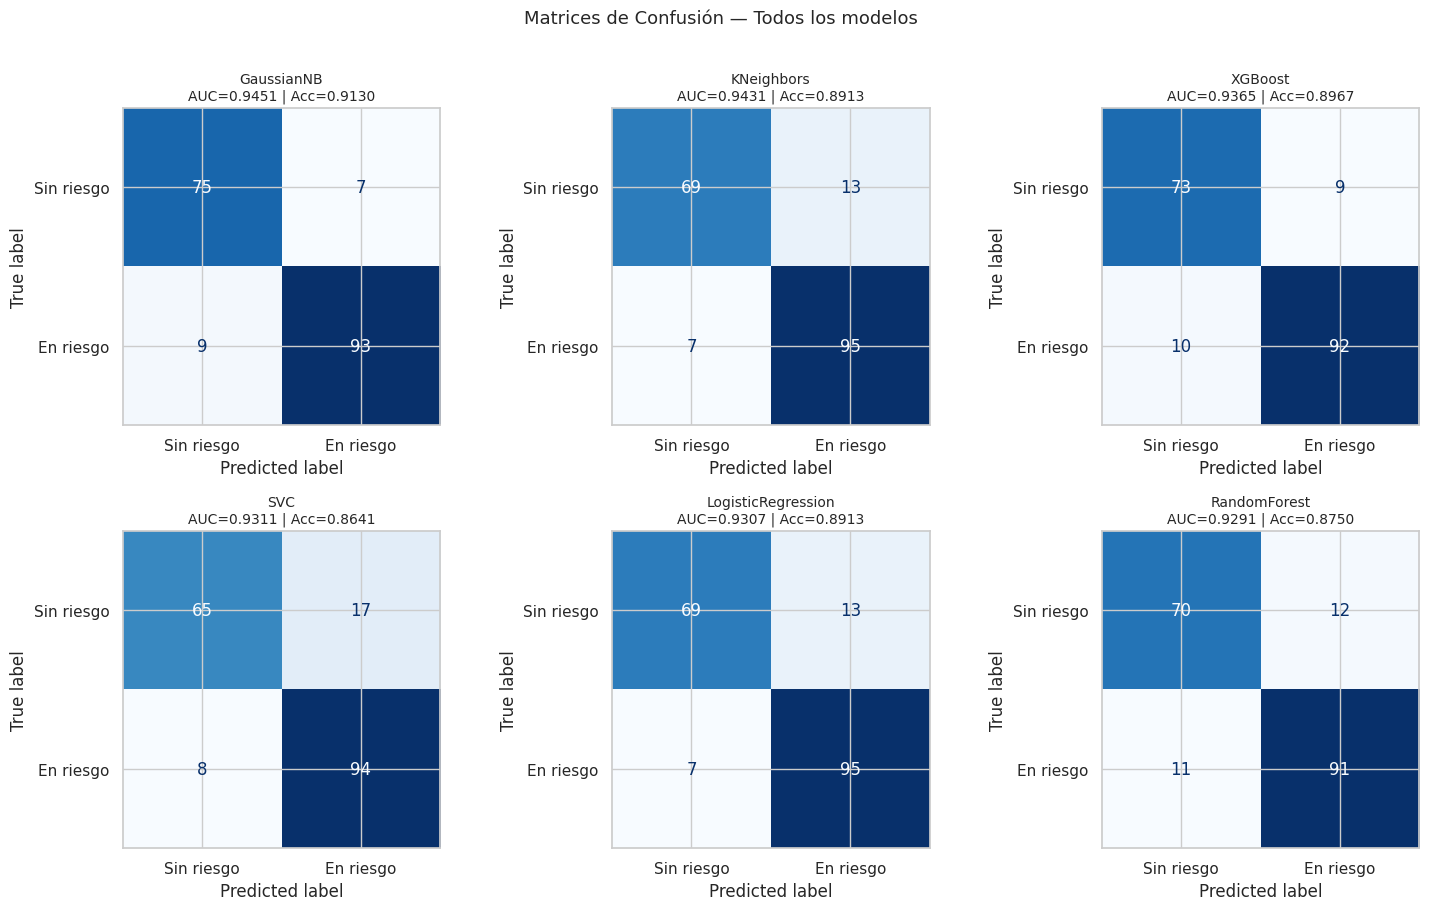

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, r in zip(axes, sorted_results):
    y_pred = r["grid"].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Sin riesgo", "En riesgo"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{r['Modelo']}\nAUC={r['AUC-ROC']:.4f} | Acc={r['Accuracy']:.4f}",
                 fontsize=10)

plt.suptitle("Matrices de Confusión — Todos los modelos", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 11. Análisis detallado del mejor modelo

In [12]:
best = sorted_results[0]
print(f" Mejor modelo: {best['Modelo']}")
print(f"{'─'*45}")
print(f"  AUC-ROC (test):        {best['AUC-ROC']}")
print(f"  AUC-ROC (CV media):    {best['CV AUC mean']}")
print(f"  Accuracy:              {best['Accuracy']}")
print(f"  F1-Score:              {best['F1-Score']}")
print(f"  Precision:             {best['Precision']}")
print(f"  Recall:                {best['Recall']}")
print(f"  Mejores hiperparámetros:")
for k, v in best['Best params'].items():
    print(f"    {k}: {v}")

print()
print("=== Reporte de clasificación completo ===")
print(classification_report(y_test, best["grid"].predict(X_test),
                             target_names=["Sin riesgo", "En riesgo"]))


 Mejor modelo: GaussianNB
─────────────────────────────────────────────
  AUC-ROC (test):        0.9451
  AUC-ROC (CV media):    0.9199
  Accuracy:              0.913
  F1-Score:              0.9208
  Precision:             0.93
  Recall:                0.9118
  Mejores hiperparámetros:
    clf__var_smoothing: 1e-09

=== Reporte de clasificación completo ===
              precision    recall  f1-score   support

  Sin riesgo       0.89      0.91      0.90        82
   En riesgo       0.93      0.91      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184



### 11.1 Estabilidad de validación cruzada del mejor modelo

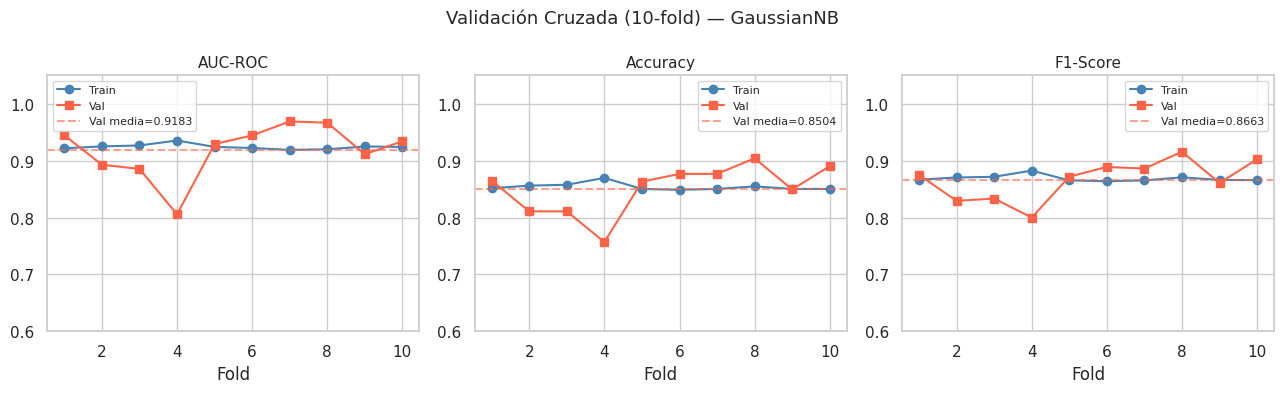

AUC-ROC CV: 0.9183 ± 0.0459
Accuracy  : 0.8504 ± 0.0426
F1-Score  : 0.8663 ± 0.0341


In [13]:
cv_results = cross_validate(
    best["grid"].best_estimator_,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring=["roc_auc", "accuracy", "f1"],
    return_train_score=True
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics_cv = [("roc_auc", "AUC-ROC"), ("accuracy", "Accuracy"), ("f1", "F1-Score")]

for ax, (key, label) in zip(axes, metrics_cv):
    train_s = cv_results[f"train_{key}"]
    test_s  = cv_results[f"test_{key}"]
    x = np.arange(1, len(train_s)+1)
    ax.plot(x, train_s, "o-", label="Train", color="steelblue")
    ax.plot(x, test_s,  "s-", label="Val",   color="tomato")
    ax.axhline(test_s.mean(), linestyle="--", color="tomato",
               alpha=0.6, label=f"Val media={test_s.mean():.4f}")
    ax.set_ylim(0.6, 1.05)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Fold")
    ax.legend(fontsize=8)

plt.suptitle(f"Validación Cruzada (10-fold) — {best['Modelo']}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"AUC-ROC CV: {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"Accuracy  : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"F1-Score  : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")


## 12. Exportar el mejor modelo para la Etapa 3

In [15]:
# Guardar el mejor estimador entrenado con todos los datos de train
final_model = best["grid"].best_estimator_
joblib.dump(final_model, "../model.joblib")

print(f"   Modelo guardado en ../model.joblib")
print(f"   Modelo: {best['Modelo']}")

   Modelo guardado en ../model.joblib
   Modelo: GaussianNB


## 13. Conclusiones

1. **División estratificada antes del escalado** — garantiza representatividad y evita leakage.
2. **`StratifiedKFold`** — mantiene la proporción de clases en cada fold de validación cruzada.
3. **`Pipeline(scaler → clf)`** — el `MinMaxScaler` sólo aprende de los datos de entrenamiento en cada fold.
4. **GridSearchCV** — optimiza hiperparámetros sin contaminar el conjunto de test.
5. **Métricas completas** — AUC, Accuracy, F1, Precision y Recall para una evaluación robusta.
6. **Estabilidad verificada** — la validación cruzada de 10 folds confirma que el modelo no sobreajusta.
7. **Modelo exportado** — `model.joblib` listo para la Etapa 3 de despliegue con FastAPI + Docker.
